### 2D line attractor system anaylsis

In [15]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from aux import format_plot
from matplotlib.colors import ListedColormap
import seaborn as sns

plt.rcParams['font.family'] = 'Helvetica'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Get a palette and convert to colormap
cmap = sns.color_palette("magma", as_cmap=True) 

In [4]:
def plot_flow_field(w, v0=0, x0=0, nonlinearity='relu', save_name='2D_flow_field', n_points=10):
    # System parameters
    tau = 1.0
    
    # ReLU function
    def relu(x):
        return np.maximum(0, x)
    
    # Define the system dynamics
    def h_dot(h):
        if nonlinearity == 'relu':
            return (w @ relu(h - v0) - h + x0) / tau
        elif nonlinearity == 'tanh':
            return (w @ np.tanh(relu(h - v0)) - h + x0) / tau
        else:
            raise NotImplementedError('Nonlinearity not found')
    
    # Grid for plotting
    x_vals = np.linspace(0, 1.2, n_points)
    y_vals = np.linspace(0, 1.2, n_points)
    X, Y = np.meshgrid(x_vals, y_vals)
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    # Evaluate vector field
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            h = np.array([X[i, j], Y[i, j]])
            dh = h_dot(h)
            U[i, j], V[i, j] = dh
    
    # Normalize vectors for quiver
    magnitude = np.sqrt(U**2 + V**2)
    U_norm = U / (magnitude + 1e-6)
    V_norm = V / (magnitude + 1e-6)
    
    # Plot
    scale = 1
    fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 3 * scale))
    m = axs.quiver(X, Y, U_norm, V_norm, magnitude, cmap=cmap)
    axs.set_xlabel('$h_1$')
    axs.set_ylabel('$h_2$')
    # axs.set_title('Flow Field for $\dot{h} = \\frac{1}{\\tau}(W [h - v]^+ - h + x_0)$')
    # axs.axvline(v[0], color='gray', linestyle='--', alpha=0.5)
    # axs.axhline(v[1], color='gray', linestyle='--', alpha=0.5)
    cbar = fig.colorbar(m, label='Speed')
    # axs.grid(True)
    axs.axis('equal')
    axs.set_xlim(0)
    axs.set_ylim(0)
    axs.set_xticks([0, 0.5, 1])
    axs.set_yticks([0, 0.5, 1])
    format_plot(axs, ticklabelsize=16, axislabelsize=16)
    format_plot(cbar.ax, ticklabelsize=16, axislabelsize=16)
    fig.savefig(f'{save_name}')
    fig.show()

### When are line attractors possible in networks of 2 units?
Aim: investigate systems of 2 neurons with symmetric weight matrices that can behave like line attractors.

I'll begin with ReLU units.

#### Two self-connected ReLU units

Dynamics obey:

$$\dot{\bf{h}} = W [h - v]^+ - h + x_0$$

where

$$
\mathbf{W} = \begin{pmatrix}
a & b \\
b & a
\end{pmatrix}
$$

and $h$ is the hidden field, $v$ is the threshold, and $x_0$ is external input.

#### Self-connected but disconnected neurons

$$
W = \begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
$$

with $x_0 = 0$, $v = 0$.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


/mmfs1/gscratch/labfairhall/davidgbe/miniconda3/envs/cont_attractor/lib/python3.13/site-packages/matplotlib/quiver.py:695: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
/mmfs1/gscratch/labfairhall/davidgbe/miniconda3/envs/cont_attractor/lib/python3.13/site-packages/matplotlib/quiver.py:695: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


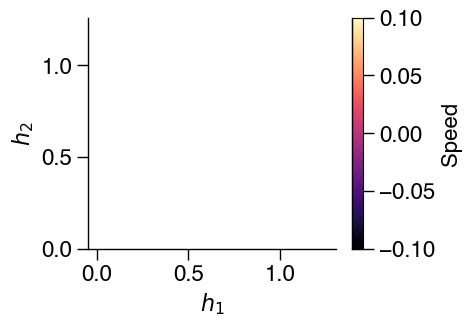

In [13]:
w = np.array([
    [1, 0],
    [0, 1],
])
plot_flow_field(w, x0=0)

#### Line attractor where units trade activity level
$0 < a < 1$, $b = a - 1$, $x_0 > 0$

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


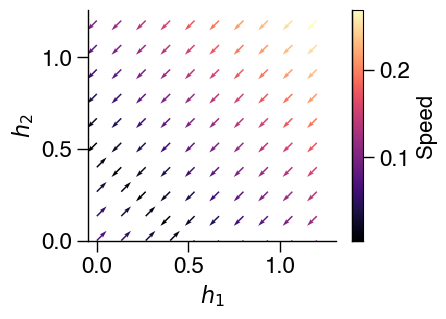

In [15]:
a = 0.9
w = np.array([
    [a, a-1],
    [a-1, a],
])
plot_flow_field(w, x0=0.05, save_name='2D_flow_line.svg')


$$
W = \begin{pmatrix}
0.9 & -0.1 \\
-0.1 & 0.9
\end{pmatrix}
$$

$$x_0 = 0.1$$


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


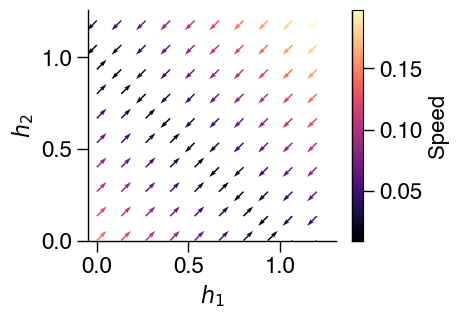

In [17]:
a = 0.9
w = np.array([
    [a, a-1],
    [a-1, a],
])
plot_flow_field(w, x0=0.1, save_name='2D_flow_line.svg')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


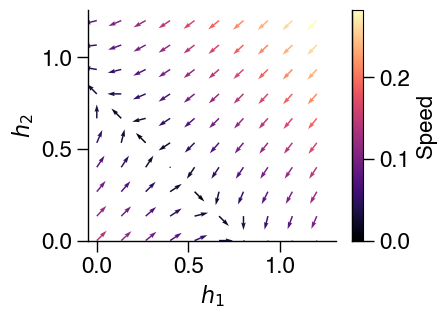

In [18]:
a = 0.9
w = np.array([
    [a, a-1.05],
    [a-1.05, a],
])
plot_flow_field(w, x0=0.1, save_name='2D_flow_line.svg')


$$
W = \begin{pmatrix}
0.9 & 0 \\
0 & 0.9
\end{pmatrix}
$$

$$x_0 = 0.1$$

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


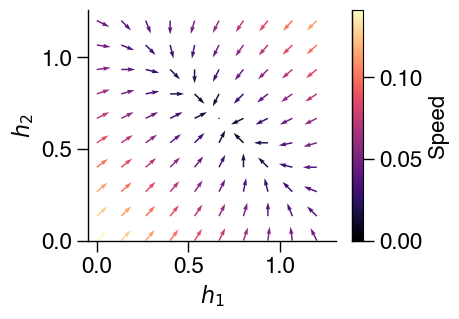

In [19]:
a = 0.9
w = np.array([
    [a, a-0.95],
    [a-0.95, a],
])
plot_flow_field(w, x0=0.1, save_name='2D_flow_line.svg')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


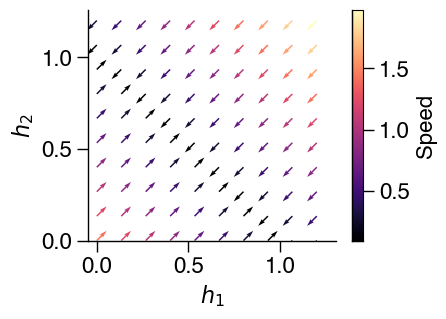

In [24]:
a = 0
w = np.array([
    [a, a-1],
    [a-1, a],
])
plot_flow_field(w, x0=1, save_name='2D_flow_line.svg')

#### Ramping solution
$a = 0$, $b = 1$, $x_0 = 0$

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


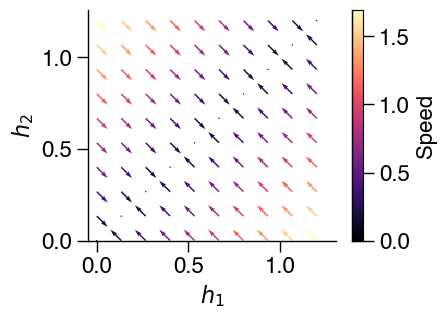

In [49]:
a = 1
w = np.array([
    [0, 1],
    [1, 0],
])
plot_flow_field(w, x0=0, save_name='2D_flow_line.svg')

#### Network with tanh nonlinearity can approximate seesaw line attractor solution

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


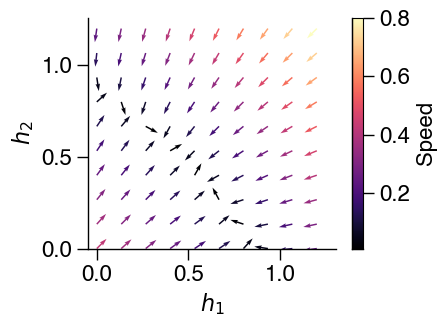

In [29]:
w = np.array([
    [0.8, -0.4],
    [-0.4, 0.8],
])
plot_flow_field(w, x0=0.3, nonlinearity='tanh')

#### With $x_0 = 0$, only saddle dynamics are possible for activity that trades off

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


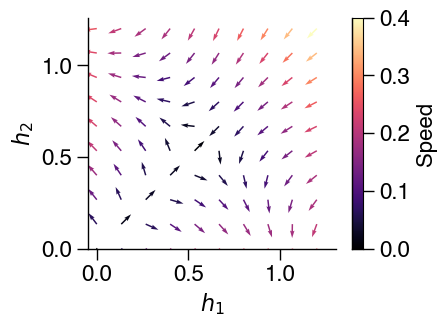

In [31]:
w = np.array([
    [1.4, -0.3],
    [-0.3, 1.4],
])
plot_flow_field(w, x0=0, nonlinearity='tanh')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


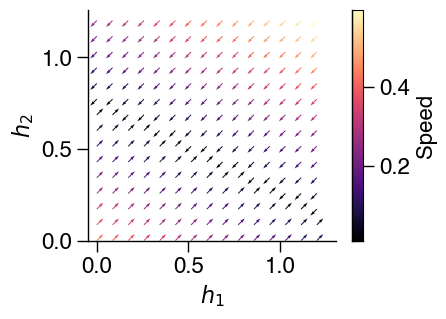

In [47]:
a1 = 0.8
a2 = 0.6
w = np.array([
    [a1, a2-1],
    [a1-1, a2],
])
plot_flow_field(w, x0=0.3, n_points=15, save_name='2D_flow_line.svg')

In [12]:
def plot_flow_field_homeo(a, save_name='2D_flow_field'):
    
    # Define the system dynamics
    def h_dot(h):
        return h[0] * (1 - h[0]) - h[1] * (1 - h[1]),  -h[0] * (1 - h[0]) + h[1] * (1  - h[1])
    
    # Grid for plotting
    x_vals = np.linspace(0, 1.2, 15)
    y_vals = np.linspace(0, 1.2, 15)
    X, Y = np.meshgrid(x_vals, y_vals)
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    # Evaluate vector field
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            h = np.array([X[i, j], Y[i, j]])
            dh = h_dot(h)
            U[i, j], V[i, j] = dh
    
    # Normalize vectors for quiver
    magnitude = np.sqrt(U**2 + V**2)
    U_norm = U / (magnitude + 1e-6)
    V_norm = V / (magnitude + 1e-6)
    
    # Plot
    scale = 1
    fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 3 * scale))
    m = axs.quiver(X, Y, U_norm, V_norm, magnitude, cmap=cmap)
    axs.set_xlabel('$h_1$')
    axs.set_ylabel('$h_2$')
    # axs.set_title('Flow Field for $\dot{h} = \\frac{1}{\\tau}(W [h - v]^+ - h + x_0)$')
    # axs.axvline(v[0], color='gray', linestyle='--', alpha=0.5)
    # axs.axhline(v[1], color='gray', linestyle='--', alpha=0.5)
    cbar = fig.colorbar(m, label='Speed')
    # axs.grid(True)
    axs.axis('equal')
    axs.set_xlim(0)
    axs.set_ylim(0)
    axs.set_xticks([0, 0.5, 1])
    axs.set_yticks([0, 0.5, 1])
    format_plot(axs, ticklabelsize=16, axislabelsize=16)
    format_plot(cbar.ax, ticklabelsize=16, axislabelsize=16)
    fig.savefig(f'{save_name}')
    fig.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


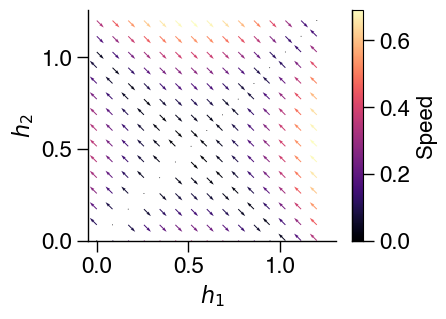

In [13]:
plot_flow_field_homeo(0)

In [ ]:
def plot_flow_field_homeo(a, save_name='2D_flow_field'):
    
    # Define the system dynamics
    def h_dot(h):
        return -h[0] * (1 - h[0]) + h[1] * (1 - h[1]),  h[0] * (1 - h[0]) - h[1] * (1  - h[1])
    
    # Grid for plotting
    x_vals = np.linspace(0, 1.2, 15)
    y_vals = np.linspace(0, 1.2, 15)
    X, Y = np.meshgrid(x_vals, y_vals)
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    # Evaluate vector field
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            h = np.array([X[i, j], Y[i, j]])
            dh = h_dot(h)
            U[i, j], V[i, j] = dh
    
    # Normalize vectors for quiver
    magnitude = np.sqrt(U**2 + V**2)
    U_norm = U / (magnitude + 1e-6)
    V_norm = V / (magnitude + 1e-6)
    
    # Plot
    scale = 1
    fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 3 * scale))
    m = axs.quiver(X, Y, U_norm, V_norm, magnitude, cmap=cmap)
    axs.set_xlabel('$w_{12}$')
    axs.set_ylabel('$w_{21}$')
    # axs.set_title('Flow Field for $\dot{h} = \\frac{1}{\\tau}(W [h - v]^+ - h + x_0)$')
    # axs.axvline(v[0], color='gray', linestyle='--', alpha=0.5)
    # axs.axhline(v[1], color='gray', linestyle='--', alpha=0.5)
    cbar = fig.colorbar(m, label='Speed')
    # axs.grid(True)
    axs.axis('equal')
    axs.set_xlim(0)
    axs.set_ylim(0)
    axs.set_xticks([0, 0.5, 1])
    axs.set_yticks([0, 0.5, 1])
    format_plot(axs, ticklabelsize=16, axislabelsize=16)
    format_plot(cbar.ax, ticklabelsize=16, axislabelsize=16)
    fig.savefig(f'{save_name}')
    fig.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


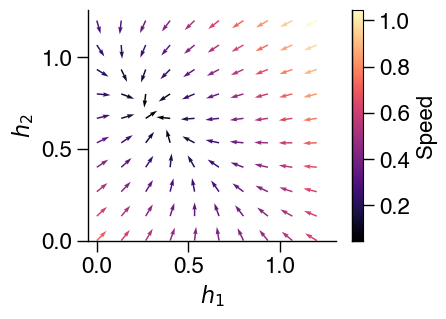

In [13]:
a = 0.5
x_1, x_2 = 0.3, 0.7
gamma = 0.5

w = np.array([
    [a - gamma * x_2, a-1 + gamma * x_1],
    [a-1 + gamma * x_2, a - gamma * x_1],
])
plot_flow_field(w, x0=0.5, save_name='2D_flow_line.svg')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


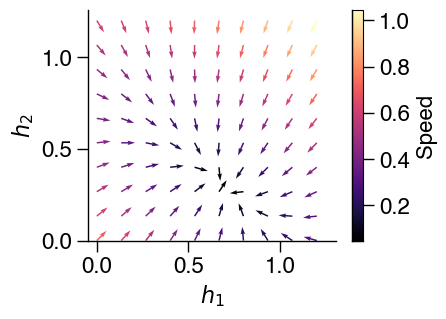

In [14]:
a = 0.5
x_1, x_2 = 0.7, 0.3
gamma = 0.5

w = np.array([
    [a - gamma * x_2, a-1 + gamma * x_1],
    [a-1 + gamma * x_2, a - gamma * x_1],
])
plot_flow_field(w, x0=0.5, save_name='2D_flow_line.svg')